# Advanced Models - Random Forest & Gradient Boosting

This notebook trains and evaluates advanced tree-based models, comparing their performance against the Logistic Regression baseline established in notebook 04.
The goal is to determine whether added model complexity produces meaningful performance improvements, particularly in recall.

Baseline benchmark to beat:
- Validation Recall: 0.9091
- Cross Validated Recall: 0.8343
- Validation Accuracy: 0.8696
- Validation F1: 0.8861

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                                confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score
import pickle

file_path = r"C:\Courses\DAMG6105\Project - Disease Prediction System"

# Load processed splits
X_train = pd.read_csv(f'{file_path}/data/processed/X_train.csv')
X_val = pd.read_csv(f'{file_path}/data/processed/X_val.csv')
X_test = pd.read_csv(f'{file_path}/data/processed/X_test.csv')
y_train = pd.read_csv(f'{file_path}/data/processed/y_train.csv').squeeze()
y_val = pd.read_csv(f'{file_path}/data/processed/y_val.csv').squeeze()
y_test = pd.read_csv(f'{file_path}/data/processed/y_test.csv').squeeze()

# Convert target to binary
y_train = y_train.apply(lambda x: 1 if x > 0 else 0)
y_val = y_val.apply(lambda x: 1 if x > 0 else 0)
y_test = y_test.apply(lambda x: 1 if x > 0 else 0)

print("Data loaded successfully.")
print("X_train shape:", X_train.shape)
print("y_train distribution:")
print(y_train.value_counts())

Data loaded successfully.
X_train shape: (644, 15)
y_train distribution:
num
1    356
0    288
Name: count, dtype: int64


In [3]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

# Make predictions on validation set
y_pred_rf = rf_model.predict(X_val)

# Evaluate
print("=== Random Forest - Validation Set Performance ===\n")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_rf):.4f}")
print("\nFull Classification Report:")
print(classification_report(y_val, y_pred_rf))

=== Random Forest - Validation Set Performance ===

Accuracy:  0.8261
Precision: 0.8118
Recall:    0.8961
F1 Score:  0.8519

Full Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.74      0.79        61
           1       0.81      0.90      0.85        77

    accuracy                           0.83       138
   macro avg       0.83      0.82      0.82       138
weighted avg       0.83      0.83      0.82       138



In [4]:
# Cross validation for Random Forest
rf_cv_scores = cross_val_score(rf_model, X_train, y_train,
                                cv=5, scoring='recall')

print("=== Random Forest — 5-Fold Cross Validation ===\n")
print("Recall score per fold:")
for i, score in enumerate(rf_cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean Recall:   {rf_cv_scores.mean():.4f}")
print(f"Std Deviation: {rf_cv_scores.std():.4f}")

=== Random Forest — 5-Fold Cross Validation ===

Recall score per fold:
  Fold 1: 0.8028
  Fold 2: 0.8451
  Fold 3: 0.8873
  Fold 4: 0.7778
  Fold 5: 0.8451

Mean Recall:   0.8316
Std Deviation: 0.0379


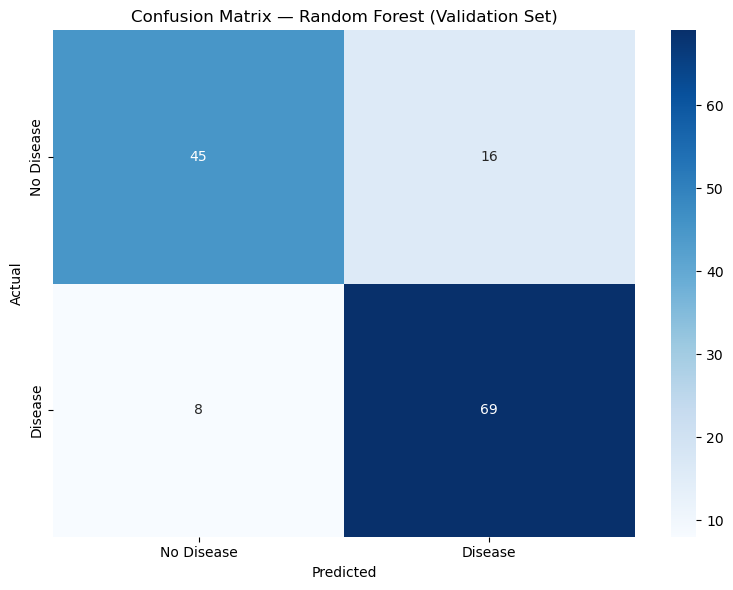

True Negatives  (correctly predicted no disease): 45
False Positives (healthy predicted as disease):   16
False Negatives (missed diagnoses):               8
True Positives  (correctly predicted disease):    69


In [5]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Random Forest (Validation Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/rf_confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"True Negatives  (correctly predicted no disease): {tn}")
print(f"False Positives (healthy predicted as disease):   {fp}")
print(f"False Negatives (missed diagnoses):               {fn}")
print(f"True Positives  (correctly predicted disease):    {tp}")

In [6]:
# Train Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions on validation set
y_pred_gb = gb_model.predict(X_val)

# Evaluate
print("=== Gradient Boosting — Validation Set Performance ===\n")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_gb):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_gb):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_gb):.4f}")
print("\nFull Classification Report:")
print(classification_report(y_val, y_pred_gb))

=== Gradient Boosting — Validation Set Performance ===

Accuracy:  0.8478
Precision: 0.8415
Recall:    0.8961
F1 Score:  0.8679

Full Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        61
           1       0.84      0.90      0.87        77

    accuracy                           0.85       138
   macro avg       0.85      0.84      0.84       138
weighted avg       0.85      0.85      0.85       138



In [7]:
# Cross validation for Gradient Boosting
gb_cv_scores = cross_val_score(gb_model, X_train, y_train,
                                cv=5, scoring='recall')

print("=== Gradient Boosting — 5-Fold Cross Validation ===\n")
print("Recall score per fold:")
for i, score in enumerate(gb_cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean Recall:   {gb_cv_scores.mean():.4f}")
print(f"Std Deviation: {gb_cv_scores.std():.4f}")

=== Gradient Boosting — 5-Fold Cross Validation ===

Recall score per fold:
  Fold 1: 0.7606
  Fold 2: 0.8592
  Fold 3: 0.8732
  Fold 4: 0.8056
  Fold 5: 0.8873

Mean Recall:   0.8372
Std Deviation: 0.0473


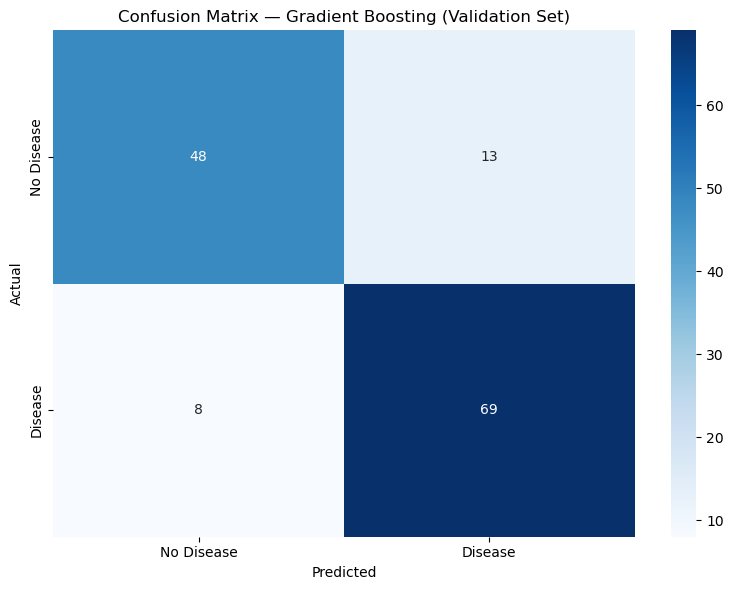

True Negatives  (correctly predicted no disease): 48
False Positives (healthy predicted as disease):   13
False Negatives (missed diagnoses):               8
True Positives  (correctly predicted disease):    69


In [8]:
# Confusion matrix for Gradient Boosting
cm_gb = confusion_matrix(y_val, y_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Gradient Boosting (Validation Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/gb_confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm_gb.ravel()
print(f"True Negatives  (correctly predicted no disease): {tn}")
print(f"False Positives (healthy predicted as disease):   {fp}")
print(f"False Negatives (missed diagnoses):               {fn}")
print(f"True Positives  (correctly predicted disease):    {tp}")

In [9]:
# Save Random Forest model
rf_path = f'{file_path}/outputs/models/random_forest.pkl'
with open(rf_path, 'wb') as f:
    pickle.dump(rf_model, f)

# Save Gradient Boosting model
gb_path = f'{file_path}/outputs/models/gradient_boosting.pkl'
with open(gb_path, 'wb') as f:
    pickle.dump(gb_model, f)

print("Models saved successfully.")
print(f"Random Forest saved to: {rf_path}")
print(f"Gradient Boosting saved to: {gb_path}")

Models saved successfully.
Random Forest saved to: C:\Courses\DAMG6105\Project - Disease Prediction System/outputs/models/random_forest.pkl
Gradient Boosting saved to: C:\Courses\DAMG6105\Project - Disease Prediction System/outputs/models/gradient_boosting.pkl


In [10]:
from sklearn.model_selection import GridSearchCV

# ── Random Forest Grid Search ──────────────────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

print("Running Grid Search for Random Forest...")
rf_grid.fit(X_train, y_train)

print("\nBest Parameters:", rf_grid.best_params_)
print("Best CV Recall: ", round(rf_grid.best_score_, 4))

Running Grid Search for Random Forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
Best CV Recall:  0.8597


In [11]:
# ── Gradient Boosting Grid Search ─────────────────────────────────────
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

print("Running Grid Search for Gradient Boosting...")
gb_grid.fit(X_train, y_train)

print("\nBest Parameters:", gb_grid.best_params_)
print("Best CV Recall: ", round(gb_grid.best_score_, 4))

Running Grid Search for Gradient Boosting...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Recall:  0.8652


In [12]:
# Evaluate tuned models on validation set
rf_best = rf_grid.best_estimator_
gb_best = gb_grid.best_estimator_

y_pred_rf_tuned = rf_best.predict(X_val)
y_pred_gb_tuned = gb_best.predict(X_val)

print("=== Tuned Random Forest — Validation Set ===")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf_tuned):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_rf_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_rf_tuned):.4f}")
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_rf_tuned).ravel()
print(f"Missed Diagnoses: {fn}")

print("\n=== Tuned Gradient Boosting — Validation Set ===")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_gb_tuned):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_gb_tuned):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_gb_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_gb_tuned):.4f}")
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_gb_tuned).ravel()
print(f"Missed Diagnoses: {fn}")

=== Tuned Random Forest — Validation Set ===
Accuracy:  0.8406
Precision: 0.8235
Recall:    0.9091
F1 Score:  0.8642
Missed Diagnoses: 7

=== Tuned Gradient Boosting — Validation Set ===
Accuracy:  0.8261
Precision: 0.7978
Recall:    0.9221
F1 Score:  0.8554
Missed Diagnoses: 6


In [13]:
# Save tuned models
rf_tuned_path = f'{file_path}/outputs/models/random_forest_tuned.pkl'
gb_tuned_path = f'{file_path}/outputs/models/gradient_boosting_tuned.pkl'

with open(rf_tuned_path, 'wb') as f:
    pickle.dump(rf_best, f)

with open(gb_tuned_path, 'wb') as f:
    pickle.dump(gb_best, f)

print("Tuned models saved successfully.")

Tuned models saved successfully.


In [14]:
from xgboost import XGBClassifier

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Make predictions on validation set
y_pred_xgb = xgb_model.predict(X_val)

# Evaluate
print("=== XGBoost — Validation Set Performance ===\n")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_xgb):.4f}")
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_xgb).ravel()
print(f"Missed Diagnoses: {fn}")

=== XGBoost — Validation Set Performance ===

Accuracy:  0.8551
Precision: 0.8434
Recall:    0.9091
F1 Score:  0.8750
Missed Diagnoses: 7


In [15]:
# Cross validation for XGBoost
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train,
                                 cv=5, scoring='recall')

print("=== XGBoost — 5-Fold Cross Validation ===\n")
print("Recall score per fold:")
for i, score in enumerate(xgb_cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean Recall:   {xgb_cv_scores.mean():.4f}")
print(f"Std Deviation: {xgb_cv_scores.std():.4f}")

=== XGBoost — 5-Fold Cross Validation ===

Recall score per fold:
  Fold 1: 0.8028
  Fold 2: 0.8732
  Fold 3: 0.8732
  Fold 4: 0.8056
  Fold 5: 0.8732

Mean Recall:   0.8456
Std Deviation: 0.0338


In [16]:
# XGBoost Grid Search
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, 
                  eval_metric='logloss',
                  verbosity=0),
    xgb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

print("Running Grid Search for XGBoost...")
xgb_grid.fit(X_train, y_train)

print("\nBest Parameters:", xgb_grid.best_params_)
print("Best CV Recall: ", round(xgb_grid.best_score_, 4))

# Evaluate tuned XGBoost on validation set
xgb_best = xgb_grid.best_estimator_
y_pred_xgb_tuned = xgb_best.predict(X_val)

print("\n=== Tuned XGBoost — Validation Set ===")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_xgb_tuned):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_xgb_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_xgb_tuned):.4f}")
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_xgb_tuned).ravel()
print(f"Missed Diagnoses: {fn}")

Running Grid Search for XGBoost...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100}
Best CV Recall:  0.854

=== Tuned XGBoost — Validation Set ===
Accuracy:  0.8261
Precision: 0.7978
Recall:    0.9221
F1 Score:  0.8554
Missed Diagnoses: 6


In [17]:
# Save tuned XGBoost model
xgb_tuned_path = f'{file_path}/outputs/models/xgboost_tuned.pkl'
with open(xgb_tuned_path, 'wb') as f:
    pickle.dump(xgb_best, f)

print("Tuned XGBoost model saved successfully.")

Tuned XGBoost model saved successfully.


# Notebook 05 Summary - Advanced Models & Model Selection

## Models Trained
- Random Forest (baseline + tuned via GridSearchCV)
- Gradient Boosting (baseline + tuned via GridSearchCV)
- XGBoost (baseline + tuned via GridSearchCV)

## Baseline Model Performance (Before Tuning)

| Metric | LR | Random Forest | Gradient Boosting | XGBoost |
|---|---|---|---|---|
| Validation Recall | 0.9091 | 0.8961 | 0.8961 | 0.9091 |
| CV Mean Recall | 0.8343 | 0.8316 | 0.8372 | 0.8456 |
| CV Std Deviation | 0.0207 | 0.0379 | 0.0473 | 0.0338 |
| Validation Accuracy | 0.8696 | 0.8261 | 0.8478 | 0.8551 |
| Validation F1 | 0.8861 | 0.8519 | 0.8679 | 0.8750 |
| Missed Diagnoses | 7 | 8 | 8 | 7 |

## Hyperparameter Tuning

### Tuned Random Forest
- Best Parameters: max_depth=7, max_features='sqrt',
  min_samples_split=10, n_estimators=100
- Best CV Recall: 0.8597 (improved from 0.8316)

### Tuned Gradient Boosting
- Best Parameters: learning_rate=0.01, max_depth=3,
  min_samples_split=2, n_estimators=100
- Best CV Recall: 0.8652 (improved from 0.8372)

### Tuned XGBoost
- Best Parameters: learning_rate=0.01, max_depth=3,
  min_child_weight=3, n_estimators=100
- Best CV Recall: 0.8540 (improved from 0.8456)

## Final Model Comparison (All Models)

| Metric | LR | RF Tuned | GB Tuned | XGB Tuned |
|---|---|---|---|---|
| Validation Recall | 0.9091 | 0.9091 | 0.9221 | 0.9221 |
| CV Recall | 0.8343 | 0.8597 | 0.8652 | 0.8540 |
| Validation Accuracy | 0.8696 | 0.8406 | 0.8261 | 0.8261 |
| Validation F1 | 0.8861 | 0.8642 | 0.8554 | 0.8554 |
| Missed Diagnoses | 7 | 7 | 6 | 6 |

## Final Model Selection - Logistic Regression

Four models were trained and evaluated, with three undergoing hyperparameter tuning via GridSearchCV optimizing for recall. Despite tuned Gradient Boosting and XGBoost achieving marginally higher recall (0.9221 vs 0.9091) and one fewer missed diagnosis, Logistic Regression was selected as the final model based on:

1. Best overall balanced performance - highest accuracy (0.8696) and F1 (0.8861)
2. Superior interpretability - feature coefficients provide direct clinical insight into prediction drivers, essential for physician trust and adoption
3. Lowest complexity - consistent with the project proposal's principle of preferring interpretable models unless complexity produces meaningful
   performance improvements
4. Best stability - lowest CV standard deviation across all models

The marginal recall difference of 0.013 does not justify sacrificing interpretability and balanced performance in a clinical decision support context.
On this structured, moderate-sized clinical dataset, the simpler interpretable model matches or outperforms complex ensemble methods - a meaningful finding that reinforces the value of model selection based on clinical context rather than raw performance metrics alone.

## Models Saved
- outputs/models/random_forest_tuned.pkl
- outputs/models/gradient_boosting_tuned.pkl
- outputs/models/xgboost_tuned.pkl